In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/clean_sme_financial_dataset.csv")

df["invoice_date"] = pd.to_datetime(df["invoice_date"])

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (249856, 28)


,transaction_id,invoice_date,store_id,region,store_type,customer_id,customer_segment,product_id,product_category,quantity,...,net_profit,payment_method,cash_collection_date,expense_payment_date,cash_inflow,cash_outflow,net_cash_flow,is_return,holiday_flag,oil_price_index
0,2316,2022-01-01,14,West,B,705.0,Regular,74,Beverages,2,...,69.23,Card,2022-01-04,2022-01-31,353.60,284.37,69.23,0,0,77.75
1,3674,2022-01-01,21,North,A,7689.0,Wholesale,11,Household,10,...,1803.37,Card,2022-01-01,2022-01-01,6456.71,4653.33,1803.38,0,0,79.72
2,5083,2022-01-01,10,Central,B,7351.0,Regular,38,Clothing,2,...,687.74,Card,2022-01-01,2022-01-01,1663.76,976.02,687.74,0,0,76.06
3,6302,2022-01-01,21,North,A,469.0,Regular,21,Electronics,3,...,481.69,Credit,2022-01-16,2022-01-01,6281.71,5800.02,481.69,0,0,75.09
4,7006,2022-01-01,14,West,B,3525.0,Regular,131,Household,2,...,218.14,UPI,2022-01-01,2022-01-01,818.61,600.46,218.15,0,0,76.31


In [2]:
monthly_revenue = (
    df.groupby(df["invoice_date"].dt.to_period("M"))["revenue"]
      .sum()
      .reset_index()
)

monthly_revenue["invoice_date"] = monthly_revenue["invoice_date"].dt.to_timestamp()

monthly_revenue.columns = ["month", "revenue"]

monthly_revenue.head(10)

,month,revenue
0,2022-01-01,13844780.66
1,2022-02-01,12538027.81
2,2022-03-01,14531335.59
3,2022-04-01,13708966.43
4,2022-05-01,13265596.77
5,2022-06-01,11907906.54
6,2022-07-01,11111954.49
7,2022-08-01,10582711.40
8,2022-09-01,10447944.08
9,2022-10-01,11757173.09


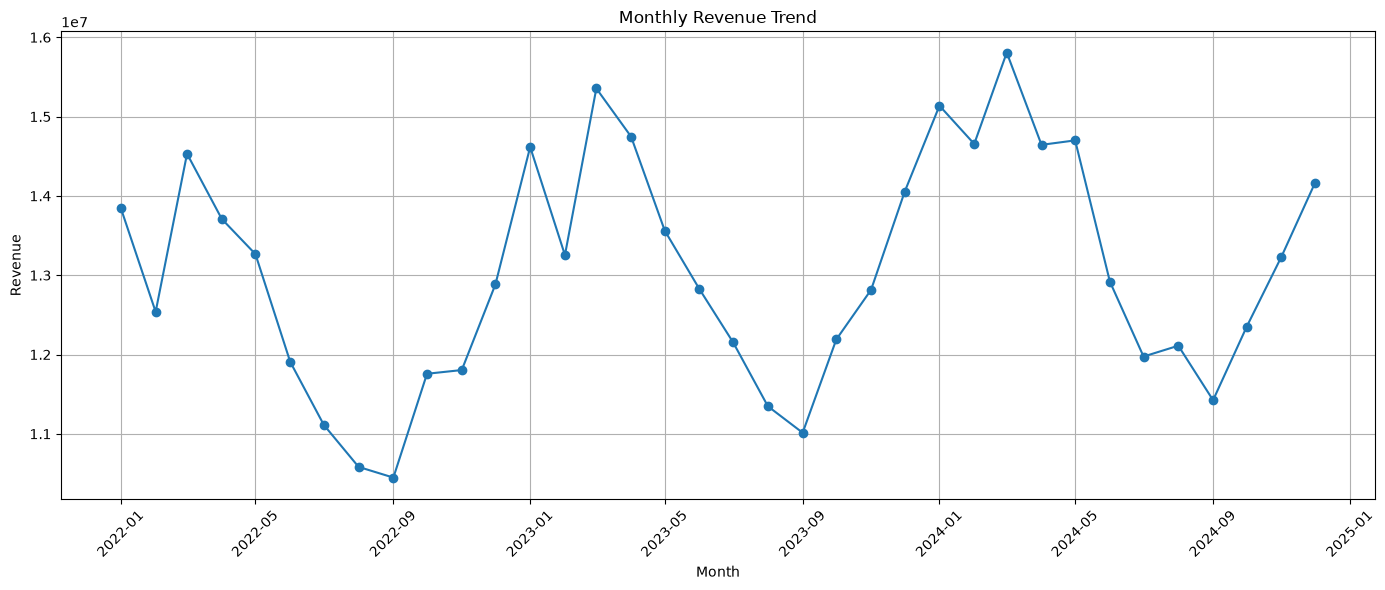

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [4]:
print("Number of months:", len(monthly_revenue))

print("\nDate range:")
print(monthly_revenue["month"].min(), "to", monthly_revenue["month"].max())

print("\nMissing values:")
print(monthly_revenue.isnull().sum())

print("\nDuplicate months:")
print(monthly_revenue["month"].duplicated().sum())

Number of months: 36

Date range:
2022-01-01 00:00:00 to 2024-12-01 00:00:00

Missing values:
month      0
revenue    0
dtype: int64

Duplicate months:
0


In [5]:
monthly_revenue["year"] = monthly_revenue["month"].dt.year
monthly_revenue["month_number"] = monthly_revenue["month"].dt.month
monthly_revenue["quarter"] = monthly_revenue["month"].dt.quarter

monthly_revenue.head(15)

,month,revenue,year,month_number,quarter
0,2022-01-01,13844780.66,2022,1,1
1,2022-02-01,12538027.81,2022,2,1
2,2022-03-01,14531335.59,2022,3,1
3,2022-04-01,13708966.43,2022,4,2
4,2022-05-01,13265596.77,2022,5,2
5,2022-06-01,11907906.54,2022,6,2
6,2022-07-01,11111954.49,2022,7,3
7,2022-08-01,10582711.40,2022,8,3
8,2022-09-01,10447944.08,2022,9,3
9,2022-10-01,11757173.09,2022,10,4


In [6]:
monthly_revenue["lag_1"] = monthly_revenue["revenue"].shift(1)
monthly_revenue["lag_2"] = monthly_revenue["revenue"].shift(2)
monthly_revenue["lag_3"] = monthly_revenue["revenue"].shift(3)
monthly_revenue["lag_12"] = monthly_revenue["revenue"].shift(12)

monthly_revenue.head(15)

,month,revenue,year,month_number,quarter,lag_1,lag_2,lag_3,lag_12
0,2022-01-01,13844780.66,2022,1,1,NaN,NaN,NaN,NaN
1,2022-02-01,12538027.81,2022,2,1,13844780.66,NaN,NaN,NaN
2,2022-03-01,14531335.59,2022,3,1,12538027.81,13844780.66,NaN,NaN
3,2022-04-01,13708966.43,2022,4,2,14531335.59,12538027.81,13844780.66,NaN
4,2022-05-01,13265596.77,2022,5,2,13708966.43,14531335.59,12538027.81,NaN
5,2022-06-01,11907906.54,2022,6,2,13265596.77,13708966.43,14531335.59,NaN
6,2022-07-01,11111954.49,2022,7,3,11907906.54,13265596.77,13708966.43,NaN
7,2022-08-01,10582711.40,2022,8,3,11111954.49,11907906.54,13265596.77,NaN
8,2022-09-01,10447944.08,2022,9,3,10582711.40,11111954.49,11907906.54,NaN
9,2022-10-01,11757173.09,2022,10,4,10447944.08,10582711.40,11111954.49,NaN


In [7]:
monthly_revenue["rolling_mean_3"] = (
    monthly_revenue["revenue"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

monthly_revenue["rolling_mean_6"] = (
    monthly_revenue["revenue"]
    .shift(1)
    .rolling(window=6)
    .mean()

)

monthly_revenue.head(15)

,month,revenue,year,month_number,quarter,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_mean_6
0,2022-01-01,13844780.66,2022,1,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-02-01,12538027.81,2022,2,1,13844780.66,NaN,NaN,NaN,NaN,NaN
2,2022-03-01,14531335.59,2022,3,1,12538027.81,13844780.66,NaN,NaN,NaN,NaN
3,2022-04-01,13708966.43,2022,4,2,14531335.59,12538027.81,13844780.66,NaN,1.363805e+07,NaN
4,2022-05-01,13265596.77,2022,5,2,13708966.43,14531335.59,12538027.81,NaN,1.359278e+07,NaN
5,2022-06-01,11907906.54,2022,6,2,13265596.77,13708966.43,14531335.59,NaN,1.383530e+07,NaN
6,2022-07-01,11111954.49,2022,7,3,11907906.54,13265596.77,13708966.43,NaN,1.296082e+07,1.329944e+07
7,2022-08-01,10582711.40,2022,8,3,11111954.49,11907906.54,13265596.77,NaN,1.209515e+07,1.284396e+07
8,2022-09-01,10447944.08,2022,9,3,10582711.40,11111954.49,11907906.54,NaN,1.120086e+07,1.251808e+07
9,2022-10-01,11757173.09,2022,10,4,10447944.08,10582711.40,11111954.49,NaN,1.071420e+07,1.183751e+07


In [8]:
monthly_revenue.isnull().sum()

month              0
revenue            0
year               0
month_number       0
quarter            0
lag_1              1
lag_2              2
lag_3              3
lag_12            12
rolling_mean_3     3
rolling_mean_6     6
dtype: int64

In [9]:
model_data = monthly_revenue.dropna().reset_index(drop=True)

print("Original rows:", len(monthly_revenue))
print("Rows after feature preparation:", len(model_data))

model_data.head()

Original rows: 36
Rows after feature preparation: 24


,month,revenue,year,month_number,quarter,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_mean_6
0,2023-01-01,14616710.90,2023,1,1,12884024.40,11804007.10,11757173.09,13844780.66,1.214840e+07,1.143130e+07
1,2023-02-01,13253986.96,2023,2,1,14616710.90,12884024.40,11804007.10,12538027.81,1.310158e+07,1.201543e+07
2,2023-03-01,15354890.02,2023,3,1,13253986.96,14616710.90,12884024.40,14531335.59,1.358491e+07,1.246064e+07
3,2023-04-01,14747206.14,2023,4,2,15354890.02,13253986.96,14616710.90,13708966.43,1.440853e+07,1.327847e+07
4,2023-05-01,13562579.92,2023,5,2,14747206.14,15354890.02,13253986.96,13265596.77,1.445203e+07,1.377680e+07


In [10]:
features = [
    "year",
    "month_number",
    "quarter",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6"
]

X = model_data[features]
y = model_data["revenue"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (24, 9)
y shape: (24,)


,year,month_number,quarter,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_mean_6
0,2023,1,1,12884024.40,11804007.10,11757173.09,13844780.66,1.214840e+07,1.143130e+07
1,2023,2,1,14616710.90,12884024.40,11804007.10,12538027.81,1.310158e+07,1.201543e+07
2,2023,3,1,13253986.96,14616710.90,12884024.40,14531335.59,1.358491e+07,1.246064e+07
3,2023,4,2,15354890.02,13253986.96,14616710.90,13708966.43,1.440853e+07,1.327847e+07
4,2023,5,2,14747206.14,15354890.02,13253986.96,13265596.77,1.445203e+07,1.377680e+07


In [11]:
train_size = 18

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining period:")
print(model_data["month"].iloc[:train_size].min(),
      "to",
      model_data["month"].iloc[:train_size].max())

print("\nTesting period:")
print(model_data["month"].iloc[train_size:].min(),
      "to",
      model_data["month"].iloc[train_size:].max())

Training data: (18, 9)
Testing data: (6, 9)

Training period:
2023-01-01 00:00:00 to 2024-06-01 00:00:00

Testing period:
2024-07-01 00:00:00 to 2024-12-01 00:00:00


In [12]:
y_pred_baseline = model_data["lag_12"].iloc[train_size:].values

print("Baseline predictions:")
print(y_pred_baseline)

Baseline predictions:
[12152761.34 11347168.31 11013404.96 12189878.55 12815445.35 14053122.37]


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

rmse_baseline = np.sqrt(
    mean_squared_error(y_test, y_pred_baseline)
)

mape_baseline = np.mean(
    np.abs((y_test - y_pred_baseline) / y_test)
) * 100

print("Baseline MAE :", mae_baseline)
print("Baseline RMSE:", rmse_baseline)
print("Baseline MAPE:", mape_baseline, "%")

Baseline MAE : 341117.62333333306
Baseline RMSE: 407822.62579466
Baseline MAPE: 2.7773966168734248 %


In [14]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost predictions:")
print(y_pred_xgb)

XGBoost predictions:
[1.2821896e+07 1.2157289e+07 1.1226326e+07 1.2819374e+07 1.2828512e+07
 1.4327831e+07]


In [15]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

mape_xgb = np.mean(
    np.abs((y_test - y_pred_xgb) / y_test)
) * 100

print("XGBoost MAE :", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)
print("XGBoost MAPE:", mape_xgb, "%")

XGBoost MAE : 354354.90666666656
XGBoost RMSE: 441420.04751496395
XGBoost MAPE: 2.863587095863744 %


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions:")
print(y_pred_rf)

Random Forest predictions:
[12699535.24593333 12087283.11075832 11776317.22379999 12319562.22271582
 12928380.91535497 14371781.51034166]


In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

sarima_result = sarima_model.fit(disp=False)

y_pred_sarima = sarima_result.forecast(steps=len(y_test))

print("SARIMA predictions:")
print(y_pred_sarima.values)

SARIMA predictions:
[12247570.23536728 11441977.20535952 11108213.85535952 12284687.44535952
 12910254.24535952 14147931.26535952]


c:\Users\Admin\Desktop\Major project\venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
c:\Users\Admin\Desktop\Major project\venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
c:\Users\Admin\Desktop\Major project\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


In [19]:
mae_sarima = mean_absolute_error(y_test, y_pred_sarima)

rmse_sarima = np.sqrt(
    mean_squared_error(y_test, y_pred_sarima)
)

mape_sarima = np.mean(
    np.abs((y_test - y_pred_sarima) / y_test)
) * 100

print("SARIMA Performance")
print("------------------")
print("MAE :", mae_sarima)
print("RMSE:", rmse_sarima)
print("MAPE:", mape_sarima, "%")

SARIMA Performance
------------------
MAE : 277911.69309494924
RMSE: 349146.07300392195
MAPE: 2.28169506831816 %


In [21]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)

print("LightGBM predictions:")
print(y_pred_lgbm)

LightGBM predictions:
[13655078.27777778 13655078.27777778 13655078.27777778 13655078.27777778
 13655078.27777778 13655078.27777778]


In [22]:
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)

rmse_lgbm = np.sqrt(
    mean_squared_error(y_test, y_pred_lgbm)
)

mape_lgbm = np.mean(
    np.abs((y_test - y_pred_lgbm) / y_test)
) * 100

print("LightGBM Performance")
print("--------------------")
print("MAE :", mae_lgbm)
print("RMSE:", rmse_lgbm)
print("MAPE:", mape_lgbm, "%")

LightGBM Performance
--------------------
MAE : 1282177.2551851852
RMSE: 1433345.690792484
MAPE: 10.61159387799985 %


In [24]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

mape_rf = np.mean(
    np.abs((y_test - y_pred_rf) / y_test)
) * 100

print("Random Forest Performance")
print("-------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("MAPE:", mape_rf, "%")

Random Forest Performance
-------------------------
MAE : 273820.6418743118
RMSE: 362141.5599548691
MAPE: 2.224059166948163 %


In [25]:
model_comparison = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "XGBoost",
        "Random Forest",
        "SARIMA",
        "LightGBM"
    ],
    "MAE": [
        mae_baseline,
        mae_xgb,
        mae_rf,
        mae_sarima,
        mae_lgbm
    ],
    "RMSE": [
        rmse_baseline,
        rmse_xgb,
        rmse_rf,
        rmse_sarima,
        rmse_lgbm
    ],
    "MAPE": [
        mape_baseline,
        mape_xgb,
        mape_rf,
        mape_sarima,
        mape_lgbm
    ]
})

model_comparison.sort_values("MAPE")

,Model,MAE,RMSE,MAPE
2,Random Forest,2.738206e+05,3.621416e+05,2.224059
3,SARIMA,2.779117e+05,3.491461e+05,2.281695
0,Seasonal Naive,3.411176e+05,4.078226e+05,2.777397
1,XGBoost,3.543549e+05,4.414200e+05,2.863587
4,LightGBM,1.282177e+06,1.433346e+06,10.611594


In [26]:
print("Total modeling observations:", len(model_data))
print("Available months:")
print(
    model_data["month"]
    .dt.strftime("%Y-%m")
    .to_list()
)

Total modeling observations: 24
Available months:
['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12']


In [27]:
initial_train_size = 12

walk_forward_splits = []

for i in range(initial_train_size, len(model_data)):
    train_indices = list(range(i))
    test_index = i

    walk_forward_splits.append(
        (train_indices, test_index)
    )

print("Number of validation rounds:", len(walk_forward_splits))

for round_no, (train_idx, test_idx) in enumerate(walk_forward_splits[:5], start=1):
    print(
        f"Round {round_no}: "
        f"Train = {model_data['month'].iloc[train_idx[0]].strftime('%Y-%m')} "
        f"to {model_data['month'].iloc[train_idx[-1]].strftime('%Y-%m')} | "
        f"Test = {model_data['month'].iloc[test_idx].strftime('%Y-%m')}"
    )

Number of validation rounds: 12
Round 1: Train = 2023-01 to 2023-12 | Test = 2024-01
Round 2: Train = 2023-01 to 2024-01 | Test = 2024-02
Round 3: Train = 2023-01 to 2024-02 | Test = 2024-03
Round 4: Train = 2023-01 to 2024-03 | Test = 2024-04
Round 5: Train = 2023-01 to 2024-04 | Test = 2024-05


In [28]:
rf_walk_forward_predictions = []
rf_walk_forward_actuals = []
rf_walk_forward_months = []

for train_idx, test_idx in walk_forward_splits:

    X_train_wf = X.iloc[train_idx]
    y_train_wf = y.iloc[train_idx]

    X_test_wf = X.iloc[[test_idx]]
    y_test_wf = y.iloc[test_idx]

    rf_model_wf = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42
    )

    rf_model_wf.fit(X_train_wf, y_train_wf)

    prediction = rf_model_wf.predict(X_test_wf)[0]

    rf_walk_forward_predictions.append(prediction)
    rf_walk_forward_actuals.append(y_test_wf)
    rf_walk_forward_months.append(
        model_data["month"].iloc[test_idx]
    )

print("Random Forest walk-forward predictions completed.")
print("Number of predictions:", len(rf_walk_forward_predictions))

Random Forest walk-forward predictions completed.
Number of predictions: 12


In [29]:
mae_rf_wf = mean_absolute_error(
    rf_walk_forward_actuals,
    rf_walk_forward_predictions
)

rmse_rf_wf = np.sqrt(
    mean_squared_error(
        rf_walk_forward_actuals,
        rf_walk_forward_predictions
    )
)

mape_rf_wf = np.mean(
    np.abs(
        (
            np.array(rf_walk_forward_actuals)
            - np.array(rf_walk_forward_predictions)
        )
        / np.array(rf_walk_forward_actuals)
    )
) * 100

print("Random Forest Walk-Forward Performance")
print("---------------------------------------")
print("MAE :", mae_rf_wf)
print("RMSE:", rmse_rf_wf)
print("MAPE:", mape_rf_wf, "%")

Random Forest Walk-Forward Performance
---------------------------------------
MAE : 446501.8437792438
RMSE: 526251.511523854
MAPE: 3.3032929168815084 %


In [31]:
xgb_walk_forward_predictions = []
xgb_walk_forward_actuals = []

for train_idx, test_idx in walk_forward_splits:

    X_train_wf = X.iloc[train_idx]
    y_train_wf = y.iloc[train_idx]

    X_test_wf = X.iloc[[test_idx]]
    y_test_wf = y.iloc[test_idx]

    xgb_model_wf = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        objective="reg:squarederror"
    )

    xgb_model_wf.fit(X_train_wf, y_train_wf)

    prediction = xgb_model_wf.predict(X_test_wf)[0]

    xgb_walk_forward_predictions.append(prediction)
    xgb_walk_forward_actuals.append(y_test_wf)

print("XGBoost walk-forward predictions completed.")
print("Number of predictions:", len(xgb_walk_forward_predictions))

XGBoost walk-forward predictions completed.
Number of predictions: 12


In [32]:
mae_xgb_wf = mean_absolute_error(
    xgb_walk_forward_actuals,
    xgb_walk_forward_predictions
)

rmse_xgb_wf = np.sqrt(
    mean_squared_error(
        xgb_walk_forward_actuals,
        xgb_walk_forward_predictions
    )
)

mape_xgb_wf = np.mean(
    np.abs(
        (
            np.array(xgb_walk_forward_actuals)
            - np.array(xgb_walk_forward_predictions)
        )
        / np.array(xgb_walk_forward_actuals)
    )
) * 100

print("XGBoost Walk-Forward Performance")
print("---------------------------------")
print("MAE :", mae_xgb_wf)
print("RMSE:", rmse_xgb_wf)
print("MAPE:", mape_xgb_wf, "%")

XGBoost Walk-Forward Performance
---------------------------------
MAE : 411944.58583333326
RMSE: 558509.5035197878
MAPE: 2.953005488222484 %


In [33]:
baseline_walk_forward_predictions = []
baseline_walk_forward_actuals = []

for train_idx, test_idx in walk_forward_splits:

    # The test month's corresponding month from the previous year
    test_month = model_data["month"].iloc[test_idx]

    previous_year_month = test_month - pd.DateOffset(years=1)

    previous_year_row = model_data[
        model_data["month"] == previous_year_month
    ]

    prediction = previous_year_row["revenue"].iloc[0]

    actual = y.iloc[test_idx]

    baseline_walk_forward_predictions.append(prediction)
    baseline_walk_forward_actuals.append(actual)

print("Seasonal Naive walk-forward predictions completed.")
print("Number of predictions:", len(baseline_walk_forward_predictions))

Seasonal Naive walk-forward predictions completed.
Number of predictions: 12


In [34]:
mae_baseline_wf = mean_absolute_error(
    baseline_walk_forward_actuals,
    baseline_walk_forward_predictions
)

rmse_baseline_wf = np.sqrt(
    mean_squared_error(
        baseline_walk_forward_actuals,
        baseline_walk_forward_predictions
    )
)

mape_baseline_wf = np.mean(
    np.abs(
        (
            np.array(baseline_walk_forward_actuals)
            - np.array(baseline_walk_forward_predictions)
        )
        / np.array(baseline_walk_forward_actuals)
    )
) * 100

print("Seasonal Naive Walk-Forward Performance")
print("----------------------------------------")
print("MAE :", mae_baseline_wf)
print("RMSE:", rmse_baseline_wf)
print("MAPE:", mape_baseline_wf, "%")

Seasonal Naive Walk-Forward Performance
----------------------------------------
MAE : 479672.78916666657
RMSE: 629117.3134455555
MAPE: 3.4751171533731 %


In [35]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

revenue_values = model_data["revenue"].values.reshape(-1, 1)

scaler = MinMaxScaler()

scaled_revenue = scaler.fit_transform(revenue_values)

print("Original shape:", revenue_values.shape)
print("Scaled shape:", scaled_revenue.shape)
print("First 5 scaled values:")
print(scaled_revenue[:5])

Original shape: (24, 1)
Scaled shape: (24, 1)
First 5 scaled values:
[[0.75168288]
 [0.46740608]
 [0.90567385]
 [0.77890539]
 [0.53178142]]


In [36]:
sequence_length = 3

X_lstm = []
y_lstm = []

for i in range(sequence_length, len(scaled_revenue)):
    X_lstm.append(
        scaled_revenue[i-sequence_length:i]
    )
    y_lstm.append(
        scaled_revenue[i]
    )

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

print("X_lstm shape:", X_lstm.shape)
print("y_lstm shape:", y_lstm.shape)

X_lstm shape: (21, 3, 1)
y_lstm shape: (21, 1)


In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential([
    LSTM(16, input_shape=(sequence_length, 1)),
    Dense(8, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()

c:\Users\Admin\Desktop\Major project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297 (5.07 KB)

 Trainable params: 1,297 (5.07 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history = lstm_model.fit(
    X_lstm,
    y_lstm,
    epochs=100,
    batch_size=4,
    verbose=0
)

print("LSTM training completed.")
print("Final training loss:", history.history["loss"][-1])

LSTM training completed.
Final training loss: 0.039413709193468094


In [40]:
lstm_walk_forward_predictions = []
lstm_walk_forward_actuals = []

sequence_length = 3

for train_idx, test_idx in walk_forward_splits:

    # Revenue available for training
    train_revenue = y.iloc[train_idx].values.reshape(-1, 1)

    # Scale only the training data
    scaler_wf = MinMaxScaler()
    train_scaled = scaler_wf.fit_transform(train_revenue)

    # Create sequences
    X_train_lstm = []
    y_train_lstm = []

    for i in range(sequence_length, len(train_scaled)):
        X_train_lstm.append(
            train_scaled[i-sequence_length:i]
        )
        y_train_lstm.append(
            train_scaled[i]
        )

    X_train_lstm = np.array(X_train_lstm)
    y_train_lstm = np.array(y_train_lstm)

    # Need enough observations to create sequences
    if len(X_train_lstm) == 0:
        continue

    # Build fresh LSTM
    model = Sequential([
        LSTM(16, input_shape=(sequence_length, 1)),
        Dense(8, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    model.fit(
        X_train_lstm,
        y_train_lstm,
        epochs=100,
        batch_size=4,
        verbose=0
    )

    # Last 3 training observations → predict next month
    last_sequence = train_scaled[-sequence_length:]
    last_sequence = last_sequence.reshape(1, sequence_length, 1)

    prediction_scaled = model.predict(
        last_sequence,
        verbose=0
    )

    prediction = scaler_wf.inverse_transform(
        prediction_scaled
    )[0, 0]

    actual = y.iloc[test_idx]

    lstm_walk_forward_predictions.append(prediction)
    lstm_walk_forward_actuals.append(actual)

print("LSTM walk-forward predictions completed.")
print("Number of predictions:", len(lstm_walk_forward_predictions))

c:\Users\Admin\Desktop\Major project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Admin\Desktop\Major project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Admin\Desktop\Major project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Admin\Desktop\Major project\venv\Lib\site-packages\keras\src\layers\rnn\r

c:\Users\Admin\Desktop\Major project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


c:\Users\Admin\Desktop\Major project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Admin\Desktop\Major project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Admin\Desktop\Major project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\Admin\Desktop\Major project\venv\Lib\site-packages\keras\src\layers\rnn\r

LSTM walk-forward predictions completed.
Number of predictions: 12


In [41]:
mae_lstm_wf = mean_absolute_error(
    lstm_walk_forward_actuals,
    lstm_walk_forward_predictions
)

rmse_lstm_wf = np.sqrt(
    mean_squared_error(
        lstm_walk_forward_actuals,
        lstm_walk_forward_predictions
    )
)

mape_lstm_wf = np.mean(
    np.abs(
        (
            np.array(lstm_walk_forward_actuals)
            - np.array(lstm_walk_forward_predictions)
        )
        / np.array(lstm_walk_forward_actuals)
    )
) * 100

print("LSTM Walk-Forward Performance")
print("-----------------------------")
print("MAE :", mae_lstm_wf)
print("RMSE:", rmse_lstm_wf)
print("MAPE:", mape_lstm_wf, "%")

LSTM Walk-Forward Performance
-----------------------------
MAE : 1097495.5008333332
RMSE: 1280206.9655630996
MAPE: 8.052518254595892 %


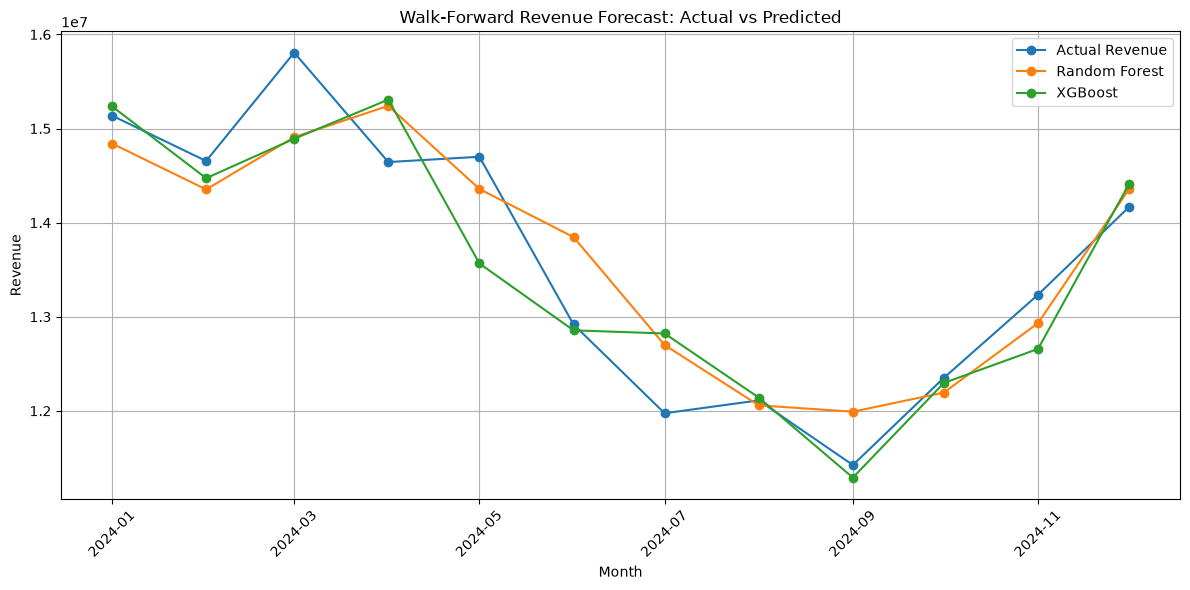

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    rf_walk_forward_months,
    rf_walk_forward_actuals,
    marker="o",
    label="Actual Revenue"
)

plt.plot(
    rf_walk_forward_months,
    rf_walk_forward_predictions,
    marker="o",
    label="Random Forest"
)

plt.plot(
    rf_walk_forward_months,
    xgb_walk_forward_predictions,
    marker="o",
    label="XGBoost"
)

plt.title("Walk-Forward Revenue Forecast: Actual vs Predicted")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()